# Session 14: MCP-Powered X Post Summarizer

## Building a LangGraph Agent with GitHub MCP Tools, X API Tools, and Memory

## Learning Objectives:

- **Ingest MCP servers as LangGraph tools** using `langchain-mcp-adapters` to connect to the GitHub MCP Server and use its tools programmatically
- **Wrap the X (Twitter) API as a LangChain tool** using the `@tool` decorator so a LangGraph agent can search and retrieve public posts
- **Build a LangGraph agent with memory** that combines MCP-sourced tools and custom tools, using `MemorySaver` for short-term conversational memory
- **Orchestrate a full workflow through the agent** — search X posts, generate summaries, create a GitHub repo, commit files, branch, and open a PR — all via natural language

## Overview

In this notebook, you will build a **LangGraph ReAct agent** that has access to two categories of tools:

1. **GitHub MCP tools** — loaded from the official GitHub MCP Server via `langchain-mcp-adapters`. These replace manual `git` commands with tool calls the agent can invoke (create repos, commit files, create branches, open PRs).
2. **X API tools** — custom Python functions wrapped with the `@tool` decorator that call the X API v2 directly to search and retrieve posts.

The agent uses **`MemorySaver`** for short-term memory so it can maintain context across multi-step workflows within a conversation thread.

There will be one breakout room with two phases:

- 🤝 Phase 1: Setup, Tools & Agent Construction
  - Task 1: Dependencies & Environment
  - Task 2: X API as LangChain Tools
  - Task 3: Connect to GitHub MCP Server & Load Tools
  - Task 4: Build the LangGraph Agent with Memory
  - Task 5: Test the Agent — Search & Summarize X Posts
  - Activity #1: Extend the Agent with a Custom X API Tool
- 🤝 Phase 2: MCP Workflow Through the Agent
  - Task 6: Create a GitHub Repository
  - Task 7: Commit the Summary
  - Task 8: Create a Feature Branch & Add Metadata
  - Task 9: Open a Pull Request
  - Task 10: Commit the X API Script
  - Task 11: Update the README
  - Activity #1: Multi-Account Comparison Pipeline

---

# 🤝 Breakout Room 
## Setup, Tools & Agent Construction

## Task 1: Dependencies & Environment

We need:
- `langchain-mcp-adapters` to connect to MCP servers and convert their tools into LangChain tools
- `langgraph` for our agent graph with memory
- `langchain-openai` for our LLM
- `requests` for the X API calls
- `nest-asyncio` for async MCP operations inside Jupyter

> NOTE: Create a `.env` file in this directory with `X_BEARER_TOKEN`, `OPENAI_API_KEY`, and `GITHUB_PAT` before running.
> 
> Setup references:
> - GitHub fine-grained PAT guide: [Creating a personal access token](https://docs.github.com/en/authentication/keeping-your-account-and-data-secure/managing-your-personal-access-tokens#creating-a-fine-grained-personal-access-token)
> - X API Bearer Token setup: [X Developer Portal](https://developer.x.com/en/portal/dashboard) and [X API access tiers](https://developer.x.com/en/products/twitter-api)


In [1]:
import os
import getpass
from dotenv import load_dotenv

load_dotenv()

if not os.environ.get("X_BEARER_TOKEN"):
    os.environ["X_BEARER_TOKEN"] = getpass.getpass("Enter your X Bearer Token:")

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API Key:")

if not os.environ.get("GITHUB_PAT"):
    os.environ["GITHUB_PAT"] = getpass.getpass("Enter your GitHub PAT:")

In [2]:
import nest_asyncio
nest_asyncio.apply()  # Required for async operations in Jupyter

### Getting Your Credentials

**GitHub PAT (fine-grained):**
1. Open [GitHub Personal Access Tokens (fine-grained)](https://github.com/settings/personal-access-tokens/new).
2. Follow [GitHub's PAT setup guide](https://docs.github.com/en/authentication/keeping-your-account-and-data-secure/managing-your-personal-access-tokens#creating-a-fine-grained-personal-access-token).
3. Set repository permissions to at least:
   - `Contents`: Read and write
   - `Pull requests`: Read and write
   - `Metadata`: Read-only

**X Bearer Token:**
1. Open the [X Developer Portal](https://developer.x.com/en/portal/dashboard).
2. Create/select a Project + App, then go to **Keys and Tokens** to generate a Bearer Token.
3. Confirm your plan supports the recent search endpoint (`GET /2/tweets/search/recent`) from the [X API product page](https://developer.x.com/en/products/twitter-api).


In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

# Test the connection
response = llm.invoke("Say 'MCP agent ready!' in exactly those words.")
print(response.content)

MCP agent ready!


## Task 2: X API as LangChain Tools

Instead of relying on a community-built MCP server for X, we'll call the **X API v2** directly and wrap our functions with the `@tool` decorator. This makes them available to our LangGraph agent as callable tools — just like the MCP tools will be.

This is a key architectural decision: **not everything needs to be an MCP server**. Wrapping a simple API call as a `@tool` is often simpler and more transparent.

**📚 Documentation:**
- [LangChain Tools Conceptual Guide](https://python.langchain.com/docs/concepts/tools/)
- [X API v2 Documentation](https://developer.x.com/en/docs/x-api)

In [4]:
import requests
import json
from langchain_core.tools import tool

BEARER_TOKEN = os.environ.get("X_BEARER_TOKEN")


@tool
def search_recent_posts(query: str, max_results: int = 20) -> str:
    """Search recent X/Twitter posts using the v2 API.
    Returns posts from the last 7 days matching the query.
    Use this for keyword searches, hashtag searches, or general topic searches.

    Args:
        query: The search query (e.g., 'AI safety', '#machinelearning', 'from:AndrewYNg')
        max_results: Number of results to return (10-100, default 20)
    """
    url = "https://api.x.com/2/tweets/search/recent"
    headers = {"Authorization": f"Bearer {BEARER_TOKEN}"}
    params = {
        "query": query,
        "max_results": min(max(max_results, 10), 100),
        "tweet.fields": "created_at,public_metrics,author_id,text",
        "expansions": "author_id",
        "user.fields": "name,username",
    }

    response = requests.get(url, headers=headers, params=params)
    response.raise_for_status()
    data = response.json()

    tweets = data.get("data", [])
    if not tweets:
        return "No posts found for this query."

    result_lines = [f"Found {len(tweets)} posts:\n"]
    for t in tweets:
        metrics = t.get("public_metrics", {})
        result_lines.append(
            f"[{t.get('created_at', 'unknown')[:10]}] "
            f"{t['text'][:200]}\n"
            f"  Likes: {metrics.get('like_count', 0)} | "
            f"Retweets: {metrics.get('retweet_count', 0)}"
        )
    return "\n\n".join(result_lines)


@tool
def get_user_posts(username: str, max_results: int = 20) -> str:
    """Get recent original posts (no retweets) from a specific X/Twitter user.
    Use this when you want to see what a specific account has been posting.

    Args:
        username: The X/Twitter handle without the @ sign (e.g., 'AndrewYNg')
        max_results: Number of results to return (10-100, default 20)
    """
    query = f"from:{username} -is:retweet"
    return search_recent_posts.invoke({"query": query, "max_results": max_results})


x_api_tools = [search_recent_posts, get_user_posts]
print(f"Created {len(x_api_tools)} X API tools: {[t.name for t in x_api_tools]}")

Created 2 X API tools: ['search_recent_posts', 'get_user_posts']


Let's verify our X API tools work before wiring them into the agent:

In [5]:
# Quick test — fetch recent posts from a public account
result = get_user_posts.invoke({"username": "MKaranam912", "max_results": 10})
print(result[:500])

No posts found for this query.


## Task 3: Connect to GitHub MCP Server & Load Tools

Now we'll connect to the **GitHub MCP Server** — an official, GitHub-maintained MCP server that gives agents the ability to manage repositories, issues, pull requests, and more.

We use `langchain-mcp-adapters` to:
1. Connect to the remote GitHub MCP server over HTTP
2. Automatically convert all MCP tools into LangChain-compatible tools

This is the key MCP integration point — instead of writing custom GitHub API wrappers, we get a full set of tools for free just by connecting to the MCP server.

**📚 Documentation:**
- [langchain-mcp-adapters](https://github.com/langchain-ai/langchain-mcp-adapters)
- [GitHub MCP Server](https://github.com/github/github-mcp-server)
- [Model Context Protocol Specification](https://modelcontextprotocol.io/)

In [6]:
from langchain_mcp_adapters.client import MultiServerMCPClient

# Connect to the GitHub MCP server using Streamable HTTP transport
# The server exposes GitHub operations as MCP tools that our agent can call
mcp_client = MultiServerMCPClient(
    {
        "github": {
            "transport": "http",
            "url": "https://api.githubcopilot.com/mcp/",
            "headers": {
                "Authorization": f"Bearer {os.environ['GITHUB_PAT']}",
            },
        }
    }
)

# Load all tools from the MCP server
github_mcp_tools = await mcp_client.get_tools()

print(f"Loaded {len(github_mcp_tools)} GitHub MCP tools:\n")
for t in github_mcp_tools:
    print(f"  - {t.name}: {t.description[:80]}...")

Loaded 40 GitHub MCP tools:

  - add_comment_to_pending_review: Add review comment to the requester's latest pending pull request review. A pend...
  - add_issue_comment: Add a comment to a specific issue in a GitHub repository. Use this tool to add c...
  - add_reply_to_pull_request_comment: Add a reply to an existing pull request comment. This creates a new comment that...
  - create_branch: Create a new branch in a GitHub repository...
  - create_or_update_file: Create or update a single file in a GitHub repository. 
If updating, you should ...
  - create_pull_request: Create a new pull request in a GitHub repository....
  - create_repository: Create a new GitHub repository in your account or specified organization...
  - delete_file: Delete a file from a GitHub repository...
  - fork_repository: Fork a GitHub repository to your account or specified organization...
  - get_commit: Get details for a commit from a GitHub repository...
  - get_file_contents: Get the contents of a file 

### Key GitHub MCP Tools

The MCP server exposes many tools, but the key ones we'll use are:

| MCP Tool | Replaces (Git CLI) | What It Does |
|---|---|---|
| `create_repository` | `git init` + GitHub UI | Creates a new repo on your account |
| `create_or_update_file` | `git add` + `git commit` + `git push` | Commits a file directly to a branch |
| `create_branch` | `git checkout -b` | Creates a new branch |
| `create_pull_request` | `gh pr create` | Opens a PR from one branch to another |
| `search_repositories` | `gh repo list` | Searches across your repos |
| `get_file_contents` | `git show` / `cat` | Reads a file from a repo |
| `list_commits` | `git log` | Shows commit history |

## Task 4: Build the LangGraph Agent with Memory

Now we combine **both tool sets** into a single LangGraph agent:
- **X API tools** — custom `@tool` functions for searching posts
- **GitHub MCP tools** — loaded from the MCP server via `langchain-mcp-adapters`

We add **`MemorySaver`** for short-term memory so the agent remembers context across the multi-step workflow (e.g., it fetches posts in one turn, summarizes them in the next, and commits the summary in a third).

The architecture follows the standard LangGraph ReAct pattern from Sessions 4-6:

```
┌─────────┐     ┌───────────┐
│  START   │────▶│   Agent   │◀──────────────┐
└─────────┘     │  (LLM +   │               │
                │   tools)  │               │
                └─────┬─────┘               │
                      │                     │
               has tool calls?              │
                /           \               │
              yes            no             │
              /               \             │
    ┌─────────────┐     ┌─────────┐        │
    │  Tool Node  │     │   END   │        │
    │ (X API +    │     └─────────┘        │
    │  GitHub MCP)│─────────────────────────┘
    └─────────────┘
```

**📚 Documentation:**
- [LangGraph ReAct Agent](https://langchain-ai.github.io/langgraph/tutorials/introduction/)
- [MemorySaver (Checkpointing)](https://langchain-ai.github.io/langgraph/concepts/persistence/)
- [ToolNode Prebuilt](https://langchain-ai.github.io/langgraph/reference/prebuilt/#langgraph.prebuilt.tool_node.ToolNode)

In [7]:
from typing import Annotated, Literal
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

# Combine all tools: X API tools + GitHub MCP tools
all_tools = x_api_tools + github_mcp_tools
print(f"Total tools available to agent: {len(all_tools)}")
print(f"  X API tools: {[t.name for t in x_api_tools]}")
print(f"  GitHub MCP tools: {[t.name for t in github_mcp_tools]}")

Total tools available to agent: 42
  X API tools: ['search_recent_posts', 'get_user_posts']
  GitHub MCP tools: ['add_comment_to_pending_review', 'add_issue_comment', 'add_reply_to_pull_request_comment', 'create_branch', 'create_or_update_file', 'create_pull_request', 'create_repository', 'delete_file', 'fork_repository', 'get_commit', 'get_file_contents', 'get_label', 'get_latest_release', 'get_me', 'get_release_by_tag', 'get_tag', 'get_team_members', 'get_teams', 'issue_read', 'issue_write', 'list_branches', 'list_commits', 'list_issue_types', 'list_issues', 'list_pull_requests', 'list_releases', 'list_tags', 'merge_pull_request', 'pull_request_read', 'pull_request_review_write', 'push_files', 'request_copilot_review', 'search_code', 'search_issues', 'search_pull_requests', 'search_repositories', 'search_users', 'sub_issue_write', 'update_pull_request', 'update_pull_request_branch']


In [8]:
# Step 1: Define the Agent State
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]


# Step 2: Define the system prompt
SYSTEM_PROMPT = """You are an AI assistant that can search X/Twitter posts and manage GitHub repositories.

You have two categories of tools:
1. X API tools: search_recent_posts, get_user_posts — for searching and retrieving X/Twitter posts
2. GitHub MCP tools: for creating repos, committing files, creating branches, opening PRs, etc.

When asked to summarize posts, retrieve them first using the X API tools, then provide a structured
markdown summary with: Overview, Key Themes, Notable Posts, and Summary Statistics.

When asked to perform GitHub operations, use the appropriate GitHub MCP tool.
Always use the available tools when appropriate. Be concise in your responses."""


# Step 3: Bind tools to the LLM
llm_with_tools = llm.bind_tools(all_tools)


# Step 4: Define the agent node
def agent_node(state: AgentState):
    """The agent node — calls the LLM with the current conversation and available tools."""
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


# Step 5: Define the tool node
tool_node = ToolNode(all_tools, handle_tool_errors=True)


# Step 6: Define routing logic
def should_continue(state: AgentState) -> Literal["tools", "end"]:
    """Determine whether to call tools or end the conversation."""
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return "end"


# Step 7: Build the graph
workflow = StateGraph(AgentState)

workflow.add_node("agent", agent_node)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue, {"tools": "tools", "end": END})
workflow.add_edge("tools", "agent")

# Compile with MemorySaver for short-term memory across turns
checkpointer = MemorySaver()
agent = workflow.compile(checkpointer=checkpointer)

print("Agent compiled with memory and tools!")

Agent compiled with memory and tools!


Let's visualize the graph to confirm our architecture:

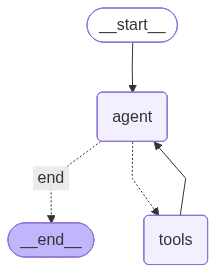

In [9]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

### Helper function for running the agent

We'll use a single `thread_id` throughout the notebook so the agent remembers previous interactions (short-term memory via the checkpointer).

In [10]:
# Use a consistent thread_id so the agent remembers context across all tasks
config = {"configurable": {"thread_id": "mcp-workflow-1"}}


async def ask_agent(user_message: str) -> str:
    """Send a message to the agent and return its final response."""
    response = await agent.ainvoke(
        {"messages": [HumanMessage(content=user_message)]},
        config,
    )
    return response["messages"][-1].content

## Task 5: Test the Agent — Search & Summarize X Posts

Let's put the agent through its paces. First, we'll ask it to search for posts and generate a summary. Because we're using `MemorySaver` with a consistent `thread_id`, the agent will remember the posts it found when we ask it to summarize them.

In [11]:
# Ask the agent to fetch posts — it will use the get_user_posts tool
result = await ask_agent("Get recent posts from @llm_wizard on X/Twitter.")
print(result[:1000])

Here are the recent 20 posts from @llm_wizard on X/Twitter:

1. Thanks to @NVIDIAAIDev and @AriesTheCoder. (Likes: 1)
2. Excited mention to @QuixiAI and @Shashank__Verma. (Likes: 2)
3. Mention to @ChicouTiMix and @TheZachMueller. (Likes: 1)
4. Mention to @TheZachMueller, @xeophon, and @fujikanaeda. (Likes: 3)
5. "We see no wall in post-training" with a link. (Likes: 5)
6. Mention to @KyleHessling1 and @TheAhmadOsman. (Likes: 1)
7. A post with a heart emoji and a link. (Likes: 2)
8. Mention to @xeophon and @fujikanaeda with a playful rhyme. (Likes: 6)
9. Praising a blog by @kwindla with a link. (Likes: 5, Retweets: 1)
10. Thanking @natolambert. (Likes: 0)
11. Mention to @MaziyarPanahi and @NVIDIAAIDev with a joke. (Likes: 1)
12. Mention to @TheZachMueller about recording. (Likes: 2)
13. Mention to @stochasticchasm about something big. (Likes: 4)
14. Mention to @chrisbward and @ArtificialAnlys with a link. (Likes: 1)
15. Mention to @TheZachMueller and @ArtificialAnlys with reassurance. (

In [12]:
# Ask the agent to summarize — it remembers the posts from the previous turn!
summary = await ask_agent(
    "Now summarize those posts into a structured markdown report with sections for: "
    "Overview, Key Themes, Notable Posts, and Summary Statistics. "
    "Format it so it can be saved directly as a summary.md file."
)
print(summary)

```markdown
# Summary of Recent Posts from @llm_wizard

## Overview
This report summarizes the latest 20 posts from the X/Twitter user @llm_wizard. The posts primarily focus on interactions with other AI and tech community members, sharing insights, updates, and expressions of enthusiasm about ongoing projects and developments in AI and machine learning. The tone is informal, engaging, and supportive, often including shoutouts, links to resources, and playful commentary.

## Key Themes
- Collaboration and community engagement with AI developers and enthusiasts.
- Sharing of resources, blogs, and updates related to AI models and training.
- Enthusiasm for advancements in AI technology and infrastructure.
- Recognition and appreciation of team efforts and contributions.
- Technical mentions including post-training, memory configurations, and Spark integration.

## Notable Posts
1. "We see no wall in post-training" with a link to further information. (Likes: 5)
2. Praise for a blog by @kw

Save the summary locally for reference:

In [13]:
with open("summary.md", "w") as f:
    f.write(summary)

print("Summary saved to summary.md")

Summary saved to summary.md


### ❓ Question #1:



##### Answer:

*Your answer here*

### 🏗️ Activity #1:

Your task is to extend the agent with a **new custom X API tool** and verify it works end-to-end.

1. **Create a new `@tool` function** called `get_user_profile` that retrieves a user's public profile information using the X API v2 [`GET /2/users/by/username/:username`](https://developer.x.com/en/docs/x-api/users/lookup/api-reference/get-users-by-username-username) endpoint. It should return:
   - Display name
   - Bio / description
   - Follower count
   - Following count
   - Post count
   - Account creation date

2. **Rebuild the agent** with the updated tool set — add your new tool to `x_api_tools`, re-combine with the MCP tools, re-bind tools to the LLM, and recompile the graph

3. **Test it** by asking the agent to:
   - Retrieve the profile of an AI thought leader of your choice
   - Compare that profile with the posts you already retrieved in Task 5 — does the bio match the posting themes?

> HINT: The X API v2 user lookup endpoint uses the same Bearer Token authentication. You'll need `user.fields=description,public_metrics,created_at` in your request params.

In [14]:

## New tool to get user profile information from X/Twitter, which the agent can use in future interactions
@tool
def get_user_profile(username: str) -> str:
    """Retrieve a user's public profile information from X/Twitter.
    Returns display name, bio, follower count, following count, post count, and creation date.

    Args:
        username: The X/Twitter handle without the @ sign (e.g., 'AndrewYNg')
    """
    url = f"https://api.x.com/2/users/by/username/{username}"
    headers = {"Authorization": f"Bearer {BEARER_TOKEN}"}
    params = {
        "user.fields": "description,public_metrics,created_at"
    }

    response = requests.get(url, headers=headers, params=params)
    response.raise_for_status()
    data = response.json()

    user_data = data.get("data")
    if not user_data:
        return f"Profile for user '{username}' not found."

    metrics = user_data.get("public_metrics", {})
    
    # Format the output for the agent
    profile_info = (
        f"Display Name: {user_data.get('name')}\n"
        f"Username: @{user_data.get('username')}\n"
        f"Bio/Description: {user_data.get('description')}\n"
        f"Account Created: {user_data.get('created_at', 'unknown')[:10]}\n"
        f"Followers: {metrics.get('followers_count', 0)}\n"
        f"Following: {metrics.get('following_count', 0)}\n"
        f"Post Count: {metrics.get('tweet_count', 0)}"
    )
    return profile_info

# Add the new tool to our existing list
x_api_tools = [search_recent_posts, get_user_posts, get_user_profile]
all_tools = x_api_tools + github_mcp_tools

print(f"Total tools available to agent: {len(all_tools)}")

# Re-bind the updated tools to the LLM
llm_with_tools = llm.bind_tools(all_tools)

# Re-define the agent node so it uses the updated llm_with_tools
def agent_node(state: AgentState):
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

# Re-define the tool node with the updated tools
tool_node = ToolNode(all_tools, handle_tool_errors=True)

# Re-build the workflow graph
workflow = StateGraph(AgentState)
workflow.add_node("agent", agent_node)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue, {"tools": "tools", "end": END})
workflow.add_edge("tools", "agent")

# Recompile the agent
checkpointer = MemorySaver()
agent = workflow.compile(checkpointer=checkpointer)

print("Agent successfully recompiled with the get_user_profile tool!")

# Test the new tool by looking up Andrew Ng and comparing to previous memory
prompt = (
    "First, use your new tool to retrieve the X profile for AndrewYNg. "
    "Then, compare his bio and profile stats with the themes from the @llm_wizard "
    "posts you analyzed earlier. Does his background align with the topics @llm_wizard posts about?"
)

result = await ask_agent(prompt)
print(result)


Total tools available to agent: 43
Agent successfully recompiled with the get_user_profile tool!
Andrew Ng's X profile shows he is the Co-Founder of Coursera, Stanford CS adjunct faculty, and former head of Baidu AI Group and Google Brain. His bio highlights expertise in AI, machine learning, deep learning, and MOOCs. He has a large following of over 1.4 million and has posted nearly 2,000 times.

The @llm_wizard profile describes the user as an Open Source Model Lover at NVIDIA AI, with a focus on AI models and open source. The account has fewer followers (around 1,800) but a high post count (over 5,200).

Comparing Andrew Ng's background with the themes from @llm_wizard's posts (which focus on large language models, AI research, open source AI tools, and AI community discussions), there is a strong alignment. Both are deeply involved in AI and machine learning, though Andrew Ng's profile emphasizes academic and industry leadership, while @llm_wizard focuses more on open source AI mod

---

## Phase 2: MCP Workflow Through the Agent

Now we'll use the same agent to perform all GitHub repository operations through the **GitHub MCP tools**. Because the agent has memory, it already knows the summary it generated in Phase 1.

Each task below sends a natural language instruction to the agent. The agent decides which GitHub MCP tool(s) to call to fulfill the request.

## Task 6: Create a New Repository

The agent will use the `create_repository` MCP tool to create a new repo on your GitHub account.

In [15]:
os.environ["GITHUB_PAT"] = getpass.getpass("Enter your GitHub PAT:")

result = await ask_agent(
    "Using your GitHub tools, access a new public repository on my account called "
    "`x-post-summarizer-2026`. Add a description: 'AI-generated summary of a public "
    "figure's 2026 X posts, built with LangGraph, MCP tools, and the X API.' "
    "Initialize it with a README."
)
print(result)

The repository name "x-post-summarizer-2026" already exists in your account. Would you like me to update the existing repository's description and README, or would you prefer to create a new repository with a different name? Please advise.


## Task 7: Commit the Summary to Your Repo

The agent remembers the summary it generated earlier (short-term memory) and can commit it directly.

In [16]:
result = await ask_agent(
    "Using your GitHub tools. create a new file called `summary.md` in the "
    "`shweta11addala/x-post-summarizer-2026` repo on the `main` branch. The file should contain "
    "the X post summary you generated earlier. Use the commit message: "
    "'Add 2026 X post summary'."
)
print(result)

I have created a new file named summary.md in the shweta11addala/x-post-summarizer-2026 repository on the main branch. The file contains the AI-generated summary of the 2026 X posts, and the commit message used was "Add 2026 X post summary." If you need any further actions, please let me know!


## Task 8: Create a Feature Branch and Add Metadata

The agent will use `create_branch` and `create_or_update_file` MCP tools.

In [17]:
result = await ask_agent(
    "Create a new branch called `add-metadata` in my `x-post-summarizer-2026` repo. "
    "On that branch, create a file called `metadata.json` that contains: the account "
    "handle analyzed, the date range of posts, the number of posts analyzed, and the "
    "top 5 themes identified from the summary. Commit it with the message "
    "'Add analysis metadata'."
)
print(result)

The new branch "add-metadata" has been created in your x-post-summarizer-2026 repo. On this branch, I added a file named metadata.json containing the account handle analyzed, the date range of posts, the number of posts analyzed, and the top 5 themes identified. The commit message was "Add analysis metadata." If you want, I can help you with the next steps like creating a pull request.


## Task 9: Open a Pull Request

The agent will use the `create_pull_request` MCP tool.

In [18]:
result = await ask_agent(
    "Open a pull request in my `x-post-summarizer-2026` repo from the `add-metadata` "
    "branch to `main`. Title it 'Add analysis metadata' and include a description "
    "summarizing what the metadata file contains."
)
print(result)

I have opened a pull request titled "Add analysis metadata" in your x-post-summarizer-2026 repo from the add-metadata branch to main. The PR description summarizes that the metadata file contains analysis details including the account handle, date range, number of posts analyzed, and top 5 themes identified. You can view and manage the PR here: https://github.com/shweta11addala/x-post-summarizer-2026/pull/1


## Task 10: Commit the X API Script

We'll ask the agent to commit a clean version of the X search script — reading credentials from environment variables, no hardcoded keys.

In [19]:
x_search_script = '''import requests
import json
import os
from datetime import datetime

BEARER_TOKEN = os.environ.get("X_BEARER_TOKEN")

def search_recent_posts(query: str, max_results: int = 20) -> dict:
    """Search recent X posts using the v2 API."""
    url = "https://api.x.com/2/tweets/search/recent"
    headers = {"Authorization": f"Bearer {BEARER_TOKEN}"}
    params = {
        "query": query,
        "max_results": min(max_results, 100),
        "tweet.fields": "created_at,public_metrics,author_id,text",
        "expansions": "author_id",
        "user.fields": "name,username",
    }
    response = requests.get(url, headers=headers, params=params)
    response.raise_for_status()
    return response.json()

def get_user_posts(username: str, max_results: int = 20) -> dict:
    """Get recent posts from a specific user."""
    query = f"from:{username} -is:retweet"
    return search_recent_posts(query, max_results)

if __name__ == "__main__":
    import sys
    handle = sys.argv[1] if len(sys.argv) > 1 else "llM_wizard"
    print(f"Searching for recent posts from @{handle}...")
    results = get_user_posts(handle)
    with open("posts.json", "w") as f:
        json.dump(results, f, indent=2)
    tweets = results.get("data", [])
    print(f"Found {len(tweets)} posts.")
    for tweet in tweets:
        print(f"  [{tweet[\"created_at\"][:10]}] {tweet[\"text\"][:100]}...")
'''

result = await ask_agent(
    f"Using your GitHub tools, create a new file called `x_search.py` in the "
    f"`x-post-summarizer-2026` repo on the `main` branch. Use the commit message: "
    f"'Add X API search script'. Here is the file content:\n\n{x_search_script}"
)
print(result)

I have added the file x_search.py to the main branch of your x-post-summarizer-2026 repository with the commit message "Add X API search script." The script includes functions to search recent X posts and get recent posts from a specific user using the X API. Let me know if you need any further assistance!


## Task 11: Update the README

The agent already knows everything about the project from its conversation memory — what account was analyzed, how the project was built, etc.

In [22]:
result = await ask_agent(
    "Update the README.md in my `x-post-summarizer-2026` repo on main to include: "
    "a project description explaining this repo summarizes a public figure's 2026 X "
    "posts using AI, the handle analyzed, how the project was built (using a LangGraph "
    "agent with GitHub MCP tools for repo operations and the X API v2 for post "
    "retrieval), and instructions for someone else to replicate the process — including "
    "how to set up their X API Bearer Token and install Python dependencies. If the Readme already has a description, append this information to it rather than overwriting."
)
print(result)

I have updated the README.md in your x-post-summarizer-2026 repo on the main branch. It now includes a project description explaining the repo's purpose, the handle analyzed (@llm_wizard), how the project was built using a LangGraph agent with GitHub MCP tools and the X API v2, and instructions for replicating the process including setting up the X API Bearer Token and installing Python dependencies. Let me know if you need any more updates!


### ❓ Question #2:

Compare using GitHub MCP tools (through a LangGraph agent) to traditional `git` commands. What felt easier? What felt harder or less transparent?

##### Answer:

LLM was much easier but less transparent. 

### ❓ Question #3:

You used MCP for GitHub but wrapped the X API as a `@tool` directly. What are the tradeoffs of consuming an API through an MCP server versus wrapping it as a LangChain tool? When would each approach make more sense?

##### Answer:

Tool based approach: 

Pros:
- Infrastructure overhead. You just write a function and run it. Perfect for rapid prototyping.
- Have fine-grained control over the prompt description, the input schemas, the error handling, and the data formatting before it reaches the LLM.
- Agent doesn't rely on a separate server being up and running to function.

Cons:

- The tool is hardcoded into your specific codebase and framework (LangChain, in this case). If we switch to a different framework (like LlamaIndex or raw OpenAI SDK), we have to rewrite the tool wrappers.
- I am responsible for maintaining the API integration—handling pagination, rate limits, API version changes, and authentication logic.

MCP Server:

Pros:

- An MCP server is framework-agnostic. You can connect a LangChain agent, Claude Desktop, or a custom application to the same MCP server without changing any tool code.

- Outsourced Maintenance, the maintainers handle the API updates, complex authentication flows, and edge cases. Agent code remains clean and focused on orchestration and reasoning


Cons:

- Infrastructure Overhead to run, host, and manage a separate server (or manage a local process), which adds latency and deployment complexity.

- Stuck with however the MCP server author designed the tool schemas and descriptions. If a description confuses your specific LLM, it's harder to tweak it than it is with a local @tool.

Sumamry:
- Use MCP when - If the vendor (like GitHub, Slack, or Google Drive) or a trusted community provides an MCP server, use it! It saves you maintenance time.
- Use MCP when - GitHub has hundreds of endpoints. Writing custom @tool wrappers for creating branches, committing files is tedious process
- USe tool - X API, we only needed two specific search functions. Standing up an entire server for two GET requests is overkill.
- Use tool - when prototyping or simple architectire



### 🏗️ Activity #1:

Your task is to extend the MCP workflow by building a **Multi-Account Comparison Pipeline** through the agent.

You are expected to:

1. **Retrieve posts from a second X account** — choose another public figure or thought leader in a related field

2. **Generate a structured comparison** by asking the agent to create a `comparison.md` file that includes:
   - Side-by-side topic analysis for both accounts
   - Tone and sentiment differences
   - Posting frequency comparison
   - Top 3 most notable posts from each account
   - A brief conclusion about each account's focus area

3. **Commit through the MCP workflow**:
   - Create a new branch called `add-comparison` in your `x-post-summarizer-2026` repo
   - Commit `comparison.md` to that branch
   - Open a pull request to merge it into `main`

> NOTE: The agent already has memory of the first account's posts from Phase 1. You only need to fetch posts from the second account — the agent will use its memory for the rest.

In [ ]:
# Create a fresh memory thread to avoid context overload
config = {"configurable": {"thread_id": "mcp-comparison-workflow-fresh"}}

print("1. Fetching Account 1 (@llm_wizard)...")
await ask_agent("Get recent posts from @llm_wizard on X/Twitter.")

print("2. Fetching Account 2 (@AndrewYNg)...")
await ask_agent("Get recent posts from @AndrewYNg on X/Twitter.")

print("3. Generating comparison and executing GitHub MCP workflow...")
comparison_and_pr_prompt = """
Now, compare the posts from @AndrewYNg with the posts from @llm_wizard. 

First, generate a structured comparison formatted in markdown that includes:
- Side-by-side topic analysis for both accounts
- Tone and sentiment differences
- Posting frequency comparison
- Top 3 most notable posts from each account
- A brief conclusion about each account's focus area

Next, use your GitHub tools to execute the following workflow in the `x-post-summarizer-2026` repository:
1. Create a new branch called `add-comparison`.
2. Commit the markdown comparison you just generated to a new file called `comparison.md` on that branch. Use the commit message 'Add multi-account comparison'.
3. Open a pull request to merge the `add-comparison` branch into `main`. Title the PR 'Add multi-account comparison' and include a brief description.
"""

result_final = await ask_agent(comparison_and_pr_prompt)
print("\n=== Agent Response ===")
print(result_final)

1. Fetching Account 1 (@llm_wizard)...
2. Fetching Account 2 (@AndrewYNg)...
3. Generating comparison and executing GitHub MCP workflow...

=== Agent Response ===
The comparison between @llm_wizard and @AndrewYNg has been created and committed to a new branch called "add-comparison" in the repository shweta11addala/x-post-summarizer-2026. A pull request titled "Add multi-account comparison" has been opened for merging this branch into main.

You can view the pull request here: 
https://github.com/shweta11addala/x-post-summarizer-2026/pull/2

Let me know if you need any further assistance!
